In [2]:
from google.colab import files
uploaded = files.upload()

Saving agriculture_yield_dataset.csv to agriculture_yield_dataset (1).csv


In [3]:
import pandas as pd

df = pd.read_csv(list(uploaded.keys())[0])

df.head()

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17


In [5]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [6]:
print("Rows and Columns:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 10 Records:")
print(df.head(10))

Rows and Columns:
(1500, 8)

Column Names:
['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare']

First 10 Records:
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   
5        831.9           28.0          190.3               2.1      6.1   
6       1023.8           32.0          108.5               6.9      6.2   
7       1142.4           18.4          241.9               4.1      7.3   
8        810.4           36.4          164.8               9.9      6.5   
9       1085.5           29.4           89.3            

In [7]:
print("Data Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nColumns with Missing Values:")
print(df.columns[df.isnull().sum() > 0])

Data Types:
rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object

Missing Values:
rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64

Columns with Missing Values:
Index([], dtype='object')


In [8]:
print(df.describe())

numeric_df = df.select_dtypes(include=np.number)

print("\nFeature with Highest Mean:")
print(numeric_df.mean().idxmax())

print("\nFeature with Highest Standard Deviation:")
print(numeric_df.std().idxmax())

       rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  \
count  1500.000000    1500.000000    1500.000000       1500.000000   
mean    754.054667      27.749467     148.744067          5.403267   
std     255.097216       5.758101      56.990279          2.584329   
min     300.200000      18.000000      50.300000          1.000000   
25%     536.175000      22.600000      98.600000          3.200000   
50%     761.200000      27.700000     146.850000          5.400000   
75%     964.375000      32.600000     196.575000          7.600000   
max    1200.000000      38.000000     249.900000         10.000000   

           soil_ph  yield_ton_per_hectare  
count  1500.000000            1500.000000  
mean      6.759133               5.028793  
std       0.719742               0.968282  
min       5.500000               2.090000  
25%       6.100000               4.337500  
50%       6.800000               5.010000  
75%       7.400000               5.740000  
max       8.00000

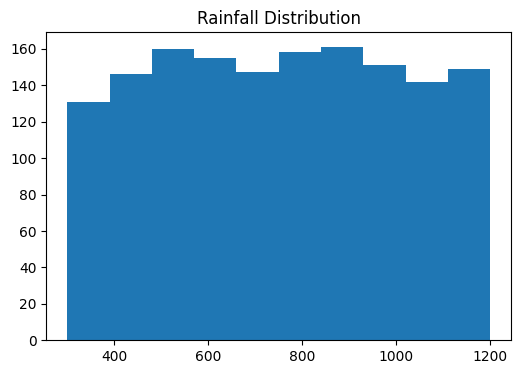

In [10]:
plt.figure(figsize=(6,4))
plt.hist(df["rainfall_mm"])
plt.title("Rainfall Distribution")
plt.show()

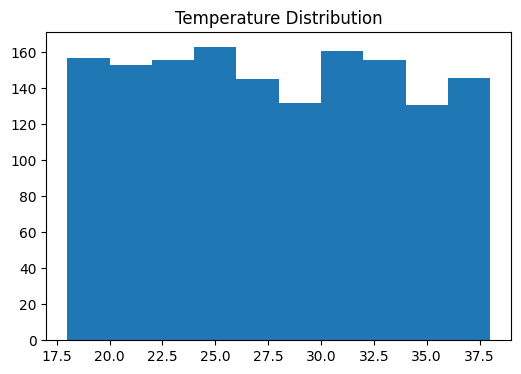

In [11]:
plt.figure(figsize=(6,4))
plt.hist(df["temperature_c"])
plt.title("Temperature Distribution")
plt.show()

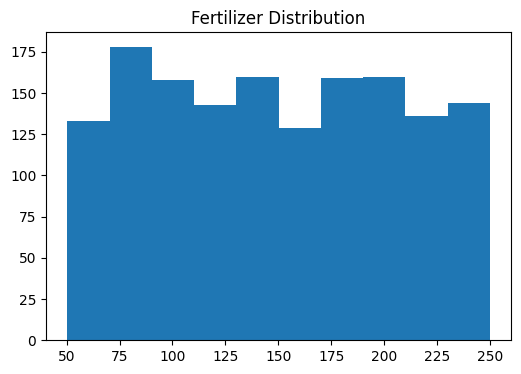

In [12]:
plt.figure(figsize=(6,4))
plt.hist(df["fertilizer_kg"])
plt.title("Fertilizer Distribution")
plt.show()

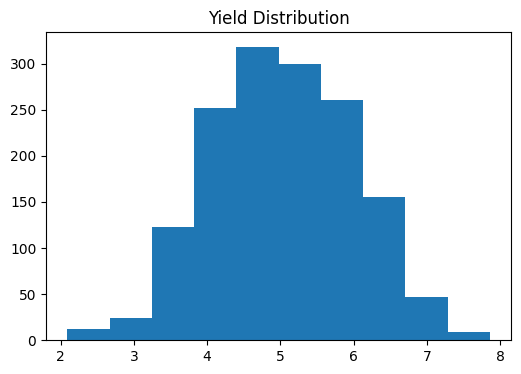

In [13]:
plt.figure(figsize=(6,4))
plt.hist(df["yield_ton_per_hectare"])
plt.title("Yield Distribution")
plt.show()

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


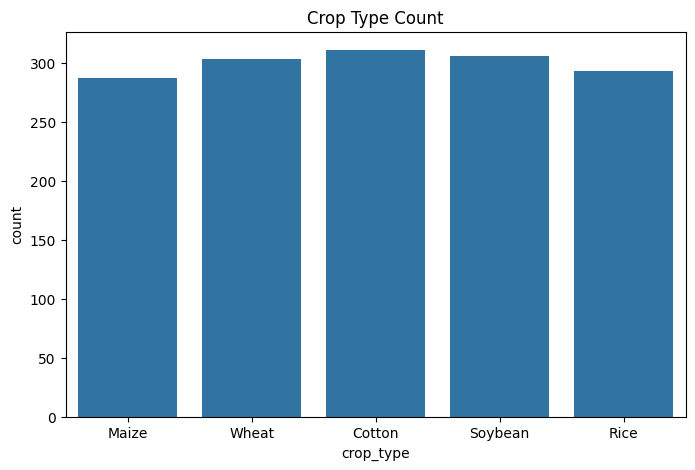


Most Frequent Crop:
Cotton


In [14]:
print(df["crop_type"].value_counts())

plt.figure(figsize=(8,5))
sns.countplot(x="crop_type", data=df)
plt.title("Crop Type Count")
plt.show()

print("\nMost Frequent Crop:")
print(df["crop_type"].value_counts().idxmax())

soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


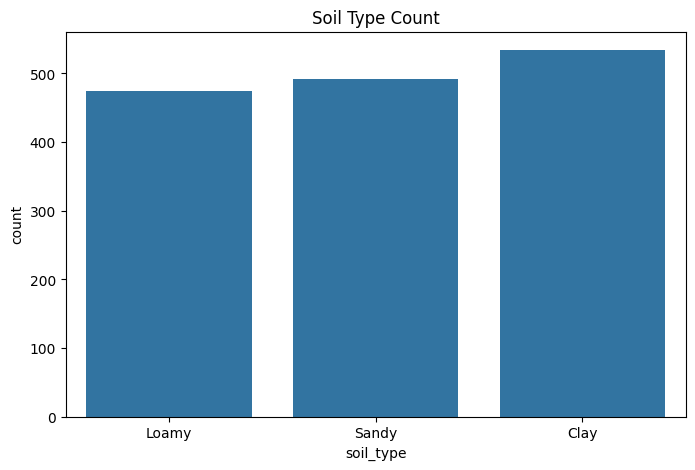


Most Common Soil Type:
Clay


In [15]:
print(df["soil_type"].value_counts())

plt.figure(figsize=(8,5))
sns.countplot(x="soil_type", data=df)
plt.title("Soil Type Count")
plt.show()

print("\nMost Common Soil Type:")
print(df["soil_type"].value_counts().idxmax())

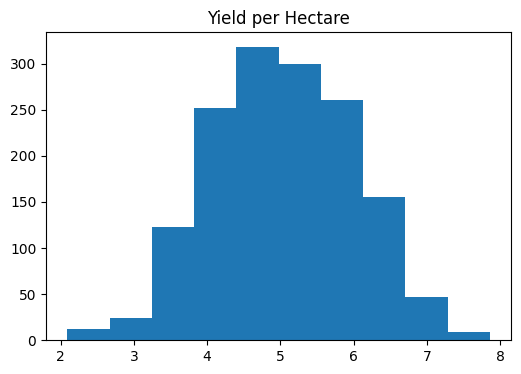

In [16]:
plt.figure(figsize=(6,4))
plt.hist(df["yield_ton_per_hectare"])
plt.title("Yield per Hectare")
plt.show()

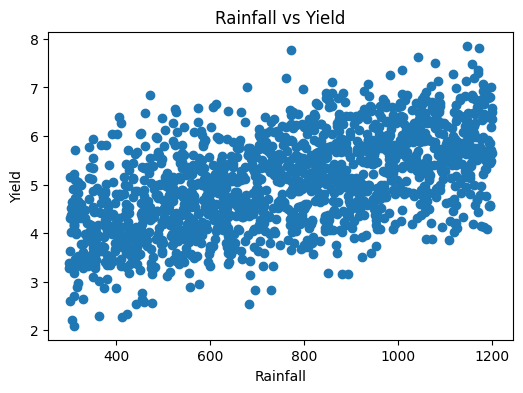

In [17]:
plt.figure(figsize=(6,4))
plt.scatter(
    df["rainfall_mm"],
    df["yield_ton_per_hectare"]
)

plt.xlabel("Rainfall")
plt.ylabel("Yield")
plt.title("Rainfall vs Yield")

plt.show()

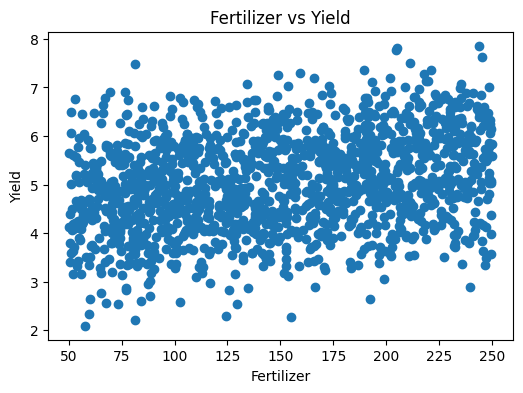

In [18]:
plt.figure(figsize=(6,4))
plt.scatter(
    df["fertilizer_kg"],
    df["yield_ton_per_hectare"]
)

plt.xlabel("Fertilizer")
plt.ylabel("Yield")
plt.title("Fertilizer vs Yield")

plt.show()

                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412               1.000000 

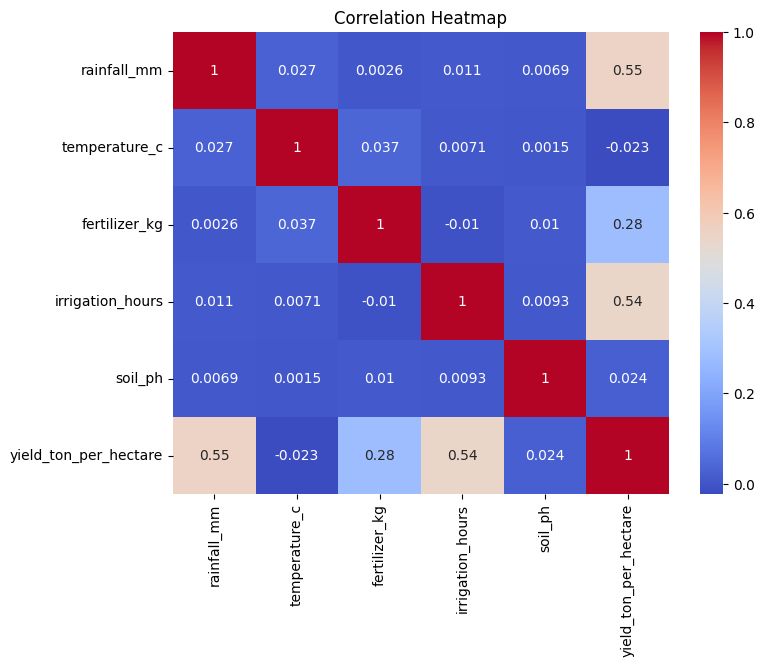

In [19]:
correlation_matrix = numeric_df.corr()

print(correlation_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [20]:
yield_corr = correlation_matrix[
    "yield_ton_per_hectare"
].sort_values(ascending=False)

print(yield_corr)

yield_ton_per_hectare    1.000000
rainfall_mm              0.553704
irrigation_hours         0.542664
fertilizer_kg            0.278043
soil_ph                  0.024412
temperature_c           -0.022559
Name: yield_ton_per_hectare, dtype: float64


In [21]:
crop_avg = df.groupby(
    "crop_type"
)["yield_ton_per_hectare"].mean()

print(crop_avg)

print("\nHighest Yield Crop:")
print(crop_avg.idxmax())

crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64

Highest Yield Crop:
Rice


In [22]:
soil_avg = df.groupby(
    "soil_type"
)["yield_ton_per_hectare"].mean()

print(soil_avg)

print("\nHighest Yield Soil:")
print(soil_avg.idxmax())

soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64

Highest Yield Soil:
Loamy


In [23]:
categorical_columns = df.select_dtypes(
    include="object"
).columns

print(categorical_columns)

df_encoded = pd.get_dummies(
    df,
    columns=categorical_columns
)

df_encoded.head()

Index(['crop_type', 'soil_type'], dtype='object')


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_Cotton,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Clay,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,5.92,False,True,False,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,6.24,False,True,False,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,4.77,False,False,False,False,True,False,False,True
3,611.7,19.0,121.7,3.7,6.0,4.04,False,True,False,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,5.17,True,False,False,False,False,True,False,False


In [24]:
X = df_encoded.drop(
    "yield_ton_per_hectare",
    axis=1
)

y = df_encoded["yield_ton_per_hectare"]

print("Target Variable:")
print("yield_ton_per_hectare")

Target Variable:
yield_ton_per_hectare


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1200, 13)
X_test: (300, 13)
y_train: (1200,)
y_test: (300,)


In [26]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Intercept:")
print(model.intercept_)

Intercept:
1.9111026182800726


In [27]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coefficients)

              Feature  Coefficient
0         rainfall_mm     0.002035
1       temperature_c    -0.009175
2       fertilizer_kg     0.004978
3    irrigation_hours     0.198327
4             soil_ph     0.004901
5    crop_type_Cotton    -0.386623
6     crop_type_Maize    -0.147693
7      crop_type_Rice     0.477369
8   crop_type_Soybean     0.095096
9     crop_type_Wheat    -0.038149
10     soil_type_Clay     0.062653
11    soil_type_Loamy     0.365627
12    soil_type_Sandy    -0.428280


In [28]:
highest_positive = coefficients.loc[
    coefficients["Coefficient"].idxmax()
]

print("Feature with Highest Positive Coefficient:")
print(highest_positive)

Feature with Highest Positive Coefficient:
Feature        crop_type_Rice
Coefficient          0.477369
Name: 7, dtype: object
